# Mental Health Score Prediction

### Problem Statement 
    The objective of this project is to build a machine learning model that predicts a students mental health score(score is continuous from 3 to 10) based on defferent factor such as social media usage, study habits, sleep, physical activity, stress level, and other available features

### 1. Import Liabraries
   We are importing liabraries for data handling, visualization, preprocessing, medels, evaluation and saving.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### 2. Load the dataset
    Loading the dataset into a Pandas DataFrame so that we can inspect, clean, analyze, and prepare the data for machine learning.

In [2]:
df = pd.read_csv("../Data/Student Social Media And Mental Health Impact.csv")

### 3. Understand the dataset
    Understanding the structure and contents of the dataset so that we can identify its columns, data types, missing values, duplicates, and basic statistics before cleaning and preparing the data for machine learning.

In [3]:
# Inspect the first five rows 
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
# Looking for number of rows and columns. 
# The dataset contain 5,000 records and 13 columns.
df.shape

(5000, 13)

In [5]:
# Column Names. 
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [6]:
# Dataset Information 
# There are 7 numerical columns and 6 categorical columns. 
# The numerical columns contain integer and floating-point values, while the categorical columns have an object data type.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [7]:
# Checking Missing values.
# The dataset contains no missing values. All 13 columns have 0 missing values.
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [8]:
# Checking duplicates records. 
# The dataset contain 2 duplicate records. 
df.duplicated().sum()

np.int64(2)

In [9]:
# Remove duplicate records. 
df = df.drop_duplicates()

In [10]:
# Statistical summary.  
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [11]:
# Target Variable Analysis.
# The target variable of this project is 'Mental_Health_Score'.
# The target has 4998 observations, with a mean of approximately 6.23 and a median of 6.10. 
# The score range from 3.6 to 9.4, showing variation in the target variable. 
df['Mental_Health_Score'].describe()

count    4998.000000
mean        6.231152
std         1.278476
min         3.600000
25%         5.100000
50%         6.100000
75%         7.100000
max         9.400000
Name: Mental_Health_Score, dtype: float64

In [12]:
# Gender Distribution 
# The dataset contain two gender categories: 
# Male: 2634 students 
# Female: 2364 students
df['Gender'].value_counts()

Gender
Male      2634
Female    2364
Name: count, dtype: int64

In [13]:
# Country Distrubution
# The country column contain students from multiple countries. 
df['Country'].value_counts()

Country
Other        1879
India         389
USA           354
Canada        230
Australia     198
             ... 
Armenia         1
Kuwait          1
Colombia        1
Bosnia          1
Croatia         1
Name: count, Length: 111, dtype: int64

In [14]:
# Observation 
# The dataset contain 111 unique country categories. 
df['Country'].nunique()

111

In [15]:
# Academic Level Distribution 
# The dataset contains three academic-level categoris:
# Undergraduate: 3,630 students 
# Graduate: 918 students 
# High School: 450 students 
# Undergraduate students represent the largest group in the dataset. 
df['Academic_Level'].value_counts()

Academic_Level
Undergraduate    3630
Graduate          918
High School       450
Name: count, dtype: int64

In [16]:
# Most used platform distrubution 
# The dataset contains 12 different social media platforms. 
df['Most_Used_Platform'].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

In [17]:
# Purpose of use distribution 
# The dataset contains four categories describing the primary purpose of social media use: 
# Entertainment: 2,551 students
# Education: 1,093 students
# Networking: 793 students
# News: 561 students
df['Purpose_Of_Use'].value_counts()

Purpose_Of_Use
Entertainment    2551
Education        1093
Networking        793
News              561
Name: count, dtype: int64

In [18]:
# Stress Level Distribution 
# The dataset contains four stress-level categories: 
# Very High: 1,621 students
# High: 1,439 students
# Medium: 1,295 students
# Low: 643 students
df['Stress_Level'].value_counts()

Stress_Level
Very High    1621
High         1439
Medium       1295
Low           643
Name: count, dtype: int64

In [19]:
# Number of unique values 
# The dataset countains both categorical and numerical variables. 
# The 'Country' column has 111 unique categories, making it the highest-cardinality categorical feature. 
# The categorical features such as 'Gender', 'Academic_level', 'Most_used_platform', 'purpose_of_use', and 'strss_level' have a relatively small number of categories.
df.nunique()

Age                          7
Gender                       2
Country                    111
Academic_Level               3
Most_Used_Platform          12
Purpose_Of_Use               4
Avg_Daily_Usage_Hours       79
Daily_Unlocks              200
Study_Hours                 76
Physical_Activity_Hours     44
Sleep_Hours_Per_Night       63
Stress_Level                 4
Mental_Health_Score         59
dtype: int64

### 4. Data Cleaning
    Cleaning the dataset by identifying and fixing missing, duplicate, invalid, or inconsistent values so that the data is ready for analysis and machine learning.

In [21]:
# Handle invalid physical_activity_values.
# We found 10 negetive values in 'Physical_Activity_Hours'. 
# Since hours cannot be negative, we replaced these invalid values with 0.
df[df['Physical_Activity_Hours'] < 0].shape

df.loc[df['Physical_Activity_Hours'] < 0, 'Physical_Activity_Hours'] = 0

In [28]:
# Check categorical consistency 
# The categorical columns contain consistent values, so no changes were required.
categorical_cols = df.select_dtypes(include='object')
for col in categorical_cols: 
    print(col, df[col].unique())

Gender ['Male' 'Female']
Country ['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany' 'Bangladesh'
 'Brazil' 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia'
 'China' 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Armenia'
 'Georgia' 'Azerbaijan' 'Cyprus' 'Malta' 'Luxembourg' 'Monaco' 'Andorra'
 'San Marino' 'Vatican City' 'Liechtenstein' 'Mont

In [30]:
# Check numerical ranges 
# The numerical values are within reasonable ranges, and no invalid values were found.
df.select_dtypes(include='number').min()

Age                        18.0
Avg_Daily_Usage_Hours       1.0
Daily_Unlocks              62.0
Study_Hours                 0.3
Physical_Activity_Hours     0.0
Sleep_Hours_Per_Night       3.6
Mental_Health_Score         3.6
dtype: float64

In [36]:
# Final cleaning verification
# The dataset has no missing values, no duplicate rows, and no negative values in 'Physical_Activity_Hours'. 
# The final dataset contains 4,998 rows and 13 columns and is ready for Exploratory Data Analysis (EDA).
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Negative physical activity:", (df['Physical_Activity_Hours'] < 0).sum())
print("Dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 0
Negative physical activity: 0
Dataset shape: (4998, 13)


### 5. Exploratory Data Analysis (EDA)
    Exploring the dataset by analyzing patterns, relationship, distributions, and important finding to better understand the data before building the machine learning model.

In [37]:
df['Mental_Health_Score'].describe()

count    4998.000000
mean        6.231152
std         1.278476
min         3.600000
25%         5.100000
50%         6.100000
75%         7.100000
max         9.400000
Name: Mental_Health_Score, dtype: float64

Text(0.5, 1.0, 'Distribution Of Mental Health Score')

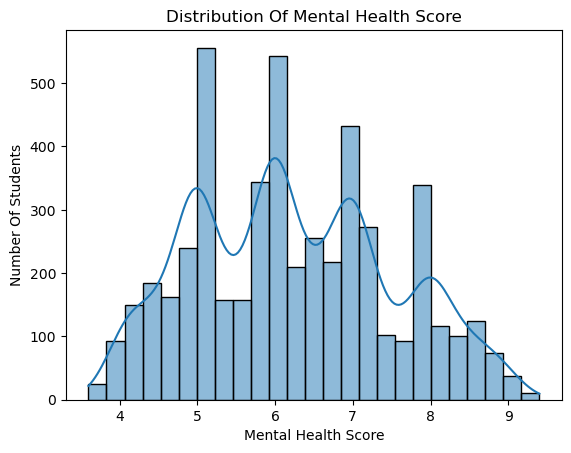

In [40]:
# Distribution of mental health score 
sns.histplot(df["Mental_Health_Score"], kde= True)
plt.xlabel("Mental Health Score")
plt.ylabel("Number Of Students")
plt.title("Distribution Of Mental Health Score")

<Axes: >

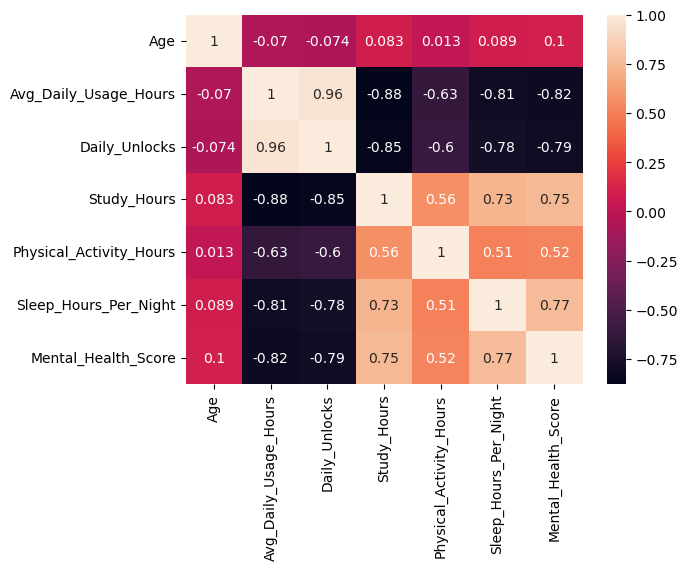

In [41]:
# Numerical features and target relationship
# We used a correlation matrix to understand the relationship between numerical features and 'Mental_Health_Score'. 
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [ ]:
# Observation 

# 1. 'Avg_Daily_Usage_Hours' and 'Daily_Unlicks' have strong negative correlations with the 'Mental_Health_Score'.
# 2. 'Sleep_Hours_Per_Night' and 'Study_Hours' have strong positve correlation with the 'Mental_Health_Score'.
# 3. 'Physical_Activity_Hours' has a moderate positive correlation, while 'Age' has a week correlation with the 'Mental_Health_Score'.

Text(0.5, 1.0, 'Stress Level By Mental Health Score')

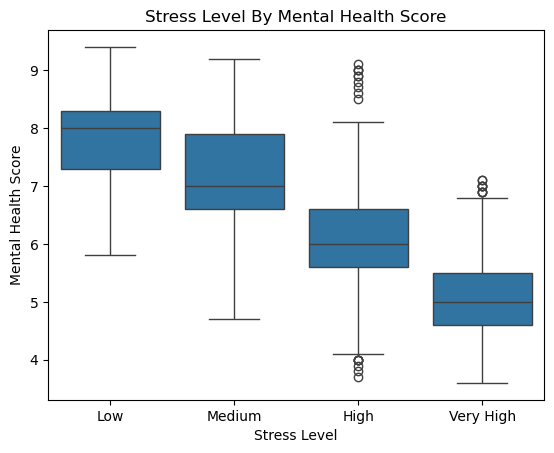

In [47]:
# Stress_Level and Mental Health Score 
order = ['Low','Medium','High','Very High']
sns.boxplot(x= 'Stress_Level', y= 'Mental_Health_Score', data= df, order= order)
plt.xlabel("Stress Level")
plt.ylabel("Mental Health Score")
plt.title("Stress Level By Mental Health Score")

In [ ]:
# Observation 

# The boxplot shows that mental health score generally decrease as stress level increases. 
# Students with low stress have higher scores, while students with very high stress have lower scores. 
# Some outliers are also present in the high and very high stress groups. 

Text(0.5, 1.0, 'Avg Daily Usage Hours By Mental Health Score')

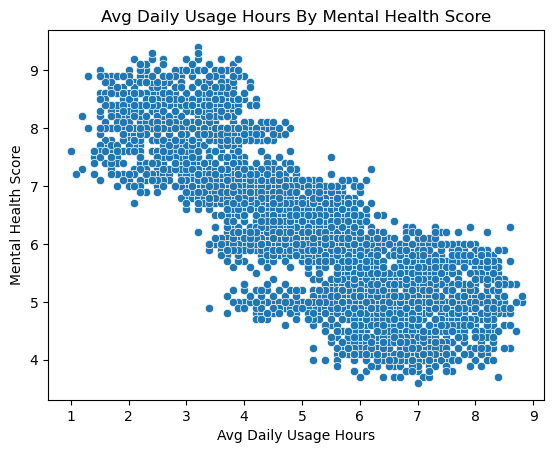

In [49]:
# Avg daily usage hours by mental health score 
sns.scatterplot(x= 'Avg_Daily_Usage_Hours', y= 'Mental_Health_Score', data= df)
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Mental Health Score")
plt.title("Avg Daily Usage Hours By Mental Health Score")

In [50]:
# Observation 

# The scatter plot shows a clear negative relationship between 'Avg_Daily_Usage_Hours' and 'Menta_Health_Score'. 
# As average daily social media usage increases, the mental health score generally decreases. 

Text(0.5, 1.0, 'Sleep hours per night By Mental health score')

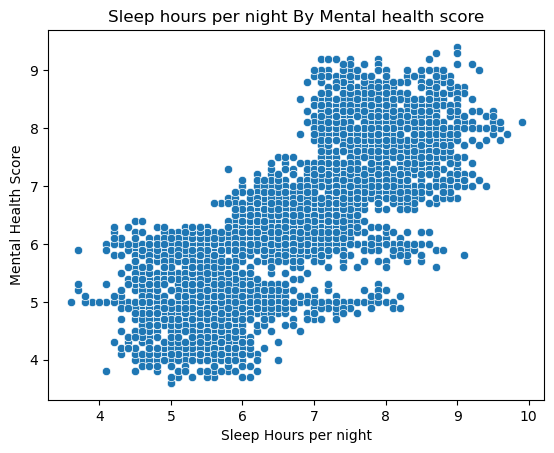

In [52]:
# Sleep hours per night By mental health score 
sns.scatterplot(x= 'Sleep_Hours_Per_Night', y= 'Mental_Health_Score', data= df)
plt.xlabel("Sleep Hours per night")
plt.ylabel('Mental Health Score')
plt.title("Sleep hours per night By Mental health score")

In [53]:
# Observation 

# The scatter plot shows a positive relationship between 'Sleep_Hours_Per_Night' and 'Menta_Health_Score'. 
# As sleep hours increase, the mental health score generally increases. 

Text(0.5, 1.0, 'Study Hours By Mental health score')

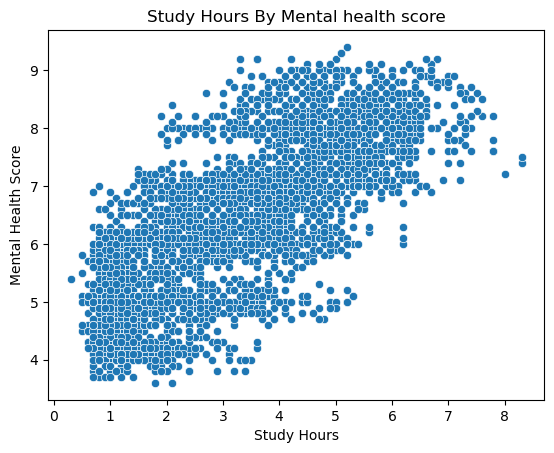

In [55]:
# Study hours By Mental health score
sns.scatterplot(x='Study_Hours', y= 'Mental_Health_Score', data= df)
plt.xlabel('Study Hours')
plt.ylabel('Mental Health Score')
plt.title("Study Hours By Mental health score")

In [ ]:
# Observation 

# The scatter plot shows a positive relationship between 'Study_Hours' and 'Mental_Health_Score'. 
# As study hours increases, the mental health score also increases. 

Text(0.5, 1.0, 'Most Used Platform')

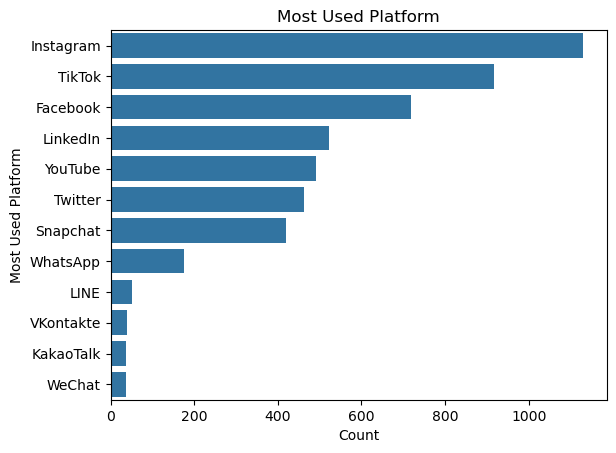

In [68]:
# Most used platform 
count = df['Most_Used_Platform'].value_counts()
sns.barplot(y= count.index, x= count.values)
plt.ylabel('Most Used Platform')
plt.xlabel('Count')
plt.title('Most Used Platform')

In [ ]:
# Observation 

# Instagram is the most commonly used platform in the dataset, followed by TikTok and Facebook. 

In [69]:
# Checking Outliers
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1 

lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR 

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    12
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [74]:
# Observation 

# The IQR method identified 2 outliers in 'Study_Hours' and 12 outliers in 'Physical_Activity_Hours'

### 6. Check Skewness
    Checking the skewness of numerical features to understand whether the data is symmetric or not.
    
    Near to 0 -> Centralized (0.01,0.001)
    Negative -> Left Skewed (-1.45)
    Positive -> Right Skewed (1.34)

In [76]:
num_cols = df.select_dtypes(include="number")
num_cols.skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [77]:
# Observations 

# Most numerical features have skewness values close to 0. 
# 'Study_Hours' has the highest skewness at 0.436, but this still relatively low. 
# Therefore, no skewness transformation is required for the numerical features at this stage. 